In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("image.jpeg", cv2.IMREAD_GRAYSCALE)

In [2]:
# ==========================================
# 1. Sobel Edge Detection
# ==========================================

sobel_x_mask = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y_mask = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

In [3]:

# ==========================================
# 2. Prewitt Edge Detection
# ==========================================

prewitt_x_mask = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

prewitt_y_mask = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])


In [4]:
# Function to apply masks
def edge_detection(image, mask_x, mask_y):

    result = np.zeros_like(image)

    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):

            region = image[i-1:i+2, j-1:j+2]

            gx = np.sum(region * mask_x)
            gy = np.sum(region * mask_y)

            value = np.sqrt(gx**2 + gy**2)

            result[i, j] = min(255, int(value))

    return result


In [6]:
# Sobel
sobel = edge_detection(image, sobel_x_mask, sobel_y_mask)

# Prewitt
prewitt = edge_detection(image, prewitt_x_mask, prewitt_y_mask)

In [7]:
# Basic Canny-style thresholding
threshold = 100

canny = np.zeros_like(sobel)

canny[sobel > threshold] = 255

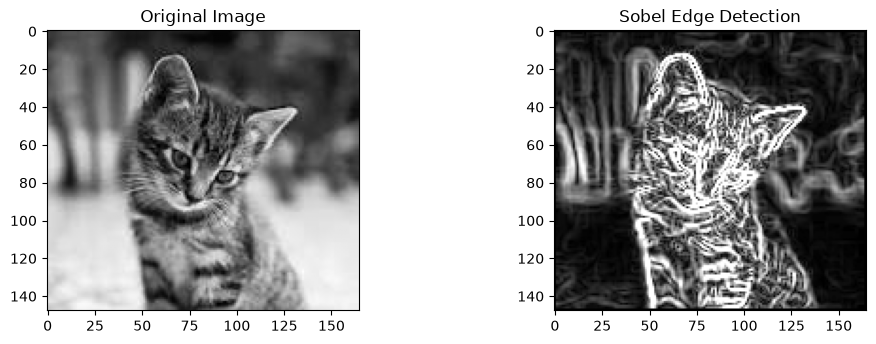

In [9]:
# Canny edge detection using OpenCV
canny_opencv = cv2.Canny(image, 100, 200)

# Display results
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.subplot(2, 2, 2)
plt.title("Sobel Edge Detection")
plt.imshow(sobel, cmap='gray')  

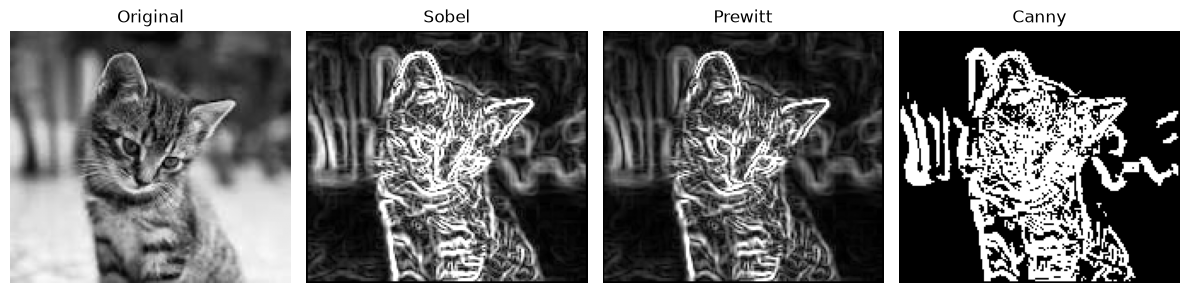

In [8]:
# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(prewitt, cmap="gray")
plt.title("Prewitt")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()